In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Loading the data
df = pd.read_csv("AB_NYC_2019.csv")

#Handling missing values
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df['last_review'] = pd.to_datetime(df['last_review'])

#Removing duplicates
df.drop_duplicates(inplace=True)

#Filtering out price outliers (e.g., price of 0 or extreme luxury)
df = df[df['price'] > 0]

print("Data Cleaned Successfully!")
print(df)


Data Cleaned Successfully!
             id                                               name   host_id  \
0          2539                 Clean & quiet apt home by the park      2787   
1          2595                              Skylit Midtown Castle      2845   
2          3647                THE VILLAGE OF HARLEM....NEW YORK !      4632   
3          3831                    Cozy Entire Floor of Brownstone      4869   
4          5022   Entire Apt: Spacious Studio/Loft by central park      7192   
...         ...                                                ...       ...   
48890  36484665    Charming one bedroom - newly renovated rowhouse   8232441   
48891  36485057      Affordable room in Bushwick/East Williamsburg   6570630   
48892  36485431            Sunny Studio at Historical Neighborhood  23492952   
48893  36485609               43rd St. Time Square-cozy single bed  30985759   
48894  36487245  Trendy duplex in the very heart of Hell's Kitchen  68119814   

           h

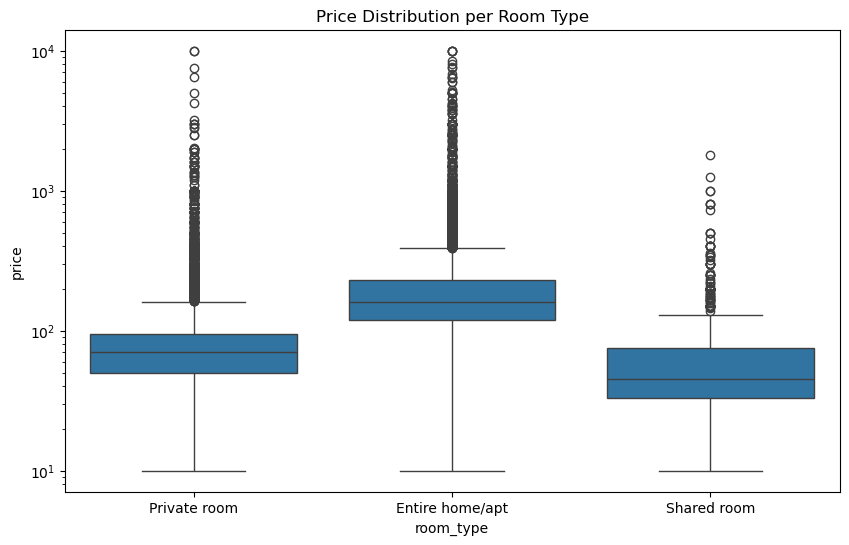

Price Distribution by Room Type
Insight: Entire homes/apartments consistently command the highest prices.
You will likely notice a significant number of 'outliers' in the private room category,
suggesting some luxury private rooms are priced similarly to entire apartments.


In [31]:
plt.figure(figsize=(10,6))
sns.boxplot(x='room_type', y='price', data=df)
plt.yscale('log') # Using log scale because NYC prices vary significantly
plt.title('Price Distribution per Room Type')
plt.show()

print("Price Distribution by Room Type")
print("Insight: Entire homes/apartments consistently command the highest prices.\n"
      "You will likely notice a significant number of 'outliers' in the private room category,\n"
      "suggesting some luxury private rooms are priced similarly to entire apartments.")

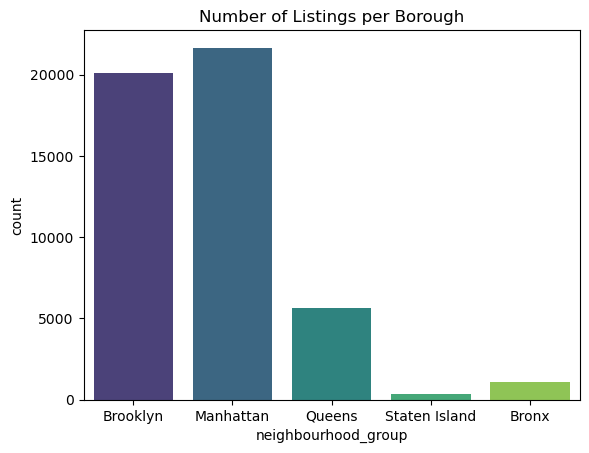

Listing Count by Neighbourhood Group
Insight: Manhattan and Brooklyn dominate the dataset.
This suggests that tourism and short-term rental demand are heavily concentrated in these two areas compared to the Bronx or Staten Island.


In [32]:
sns.countplot(
    x='neighbourhood_group', 
    data=df, 
    hue='neighbourhood_group',  #Assigning x to hue
    palette='viridis', 
    legend=False                #Hides the redundant legend
)
plt.title('Number of Listings per Borough')
plt.show()

print("Listing Count by Neighbourhood Group")
print("Insight: Manhattan and Brooklyn dominate the dataset.\n"
      "This suggests that tourism and short-term rental demand are heavily concentrated in these two areas compared to the Bronx or Staten Island.")

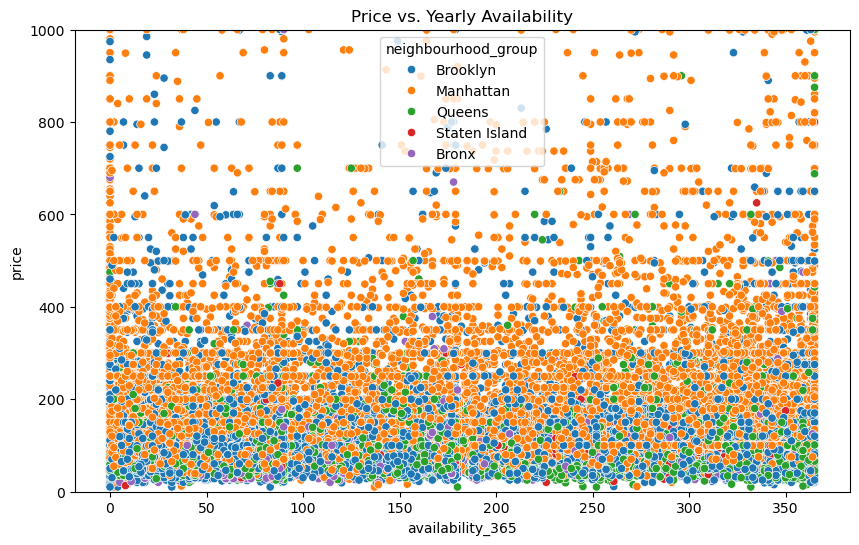

Relationship between Price and Availability
Insight: There is often a 'cluster' of low-availability listings at various price points,
indicating 'hot' properties that stay booked. Listings with 365-day availability are frequently professionally managed or dedicated rental spaces rather than personal homes.


In [33]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='availability_365', y='price', hue='neighbourhood_group', data=df)
plt.ylim(0, 1000) # Capping price for better visibility
plt.title('Price vs. Yearly Availability')
plt.show()

print("Relationship between Price and Availability")
print("Insight: There is often a 'cluster' of low-availability listings at various price points,\n"
      "indicating 'hot' properties that stay booked. Listings with 365-day availability are frequently professionally managed or dedicated rental spaces rather than personal homes.")